# Statevector Estimator Example
## Modified for Quantum Rings  toolkit for Qiskit 2.x
#### See Here: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorEstimator

### Install Required Packages

In [ ]:
%%capture
%pip install quantumrings-toolkit-qiskit
%pip install qiskit

In [2]:
#
# Setup your account
# You can also save your account locally using the class method QrRuntimeService.save_account(...) and
# invoke the QrRuntimeService class constructor without any arguments.
#
import os
my_token = os.environ["QR_TOKEN"]
my_name = os.environ["QR_ACCOUNT"]

#
# Set the backend of your choice, depending upon the task and your hardware configuration.
# See SDK documentation for additional help.
#

my_backend = "scarlet_quantum_rings"

In [3]:
# Import from Quantum Rings Toolkit
from quantumrings.toolkit.qiskit import QrRuntimeService

# Acquire Quantum Rings backend
qr_services = QrRuntimeService(name = my_name, token = my_token)
qr_backend = qr_services.backend(name = my_backend, precision = "single")

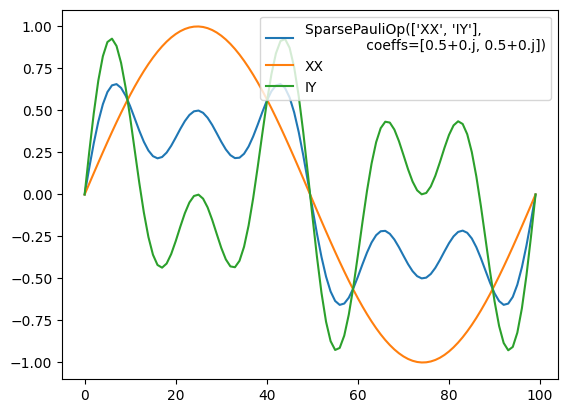

In [4]:
from qiskit.circuit import Parameter, QuantumCircuit
#from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import Pauli, SparsePauliOp

from quantumrings.toolkit.qiskit import QrStatevectorEstimator
 
import matplotlib.pyplot as plt
import numpy as np
 
# Define a circuit with two parameters.
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)
circuit.ry(Parameter("a"), 0)
circuit.rz(Parameter("b"), 0)
circuit.cx(0, 1)
circuit.h(0)
 
# Define a sweep over parameter values, where the second axis is over
# the two parameters in the circuit.
params = np.vstack([
    np.linspace(-np.pi, np.pi, 100),
    np.linspace(-4 * np.pi, 4 * np.pi, 100)
]).T
 
# Define three observables. Many formats are supported here including
# classes such as qiskit.quantum_info.SparsePauliOp. The inner length-1
# lists cause this array of observables to have shape (3, 1), rather
# than shape (3,) if they were omitted.
observables = [
    [SparsePauliOp(["XX", "IY"], [0.5, 0.5])],
    [Pauli("XX")],
    [Pauli("IY")]
]
 
# Instantiate a new statevector simulation based estimator object.
estimator = QrStatevectorEstimator(backend = qr_backend)
 
# Estimate the expectation value for all 300 combinations of
# observables and parameter values, where the pub result will have
# shape (3, 100). This shape is due to our array of parameter
# bindings having shape (100,), combined with our array of observables
# having shape (3, 1)
pub = (circuit, observables, params)
job = estimator.run([pub])
 
# Extract the result for the 0th pub (this example only has one pub).
result = job.result()[0]
 
# Error-bar information is also available, but the error is 0
# for this StatevectorEstimator.
result.data.stds
 
# Pull out the array-based expectation value estimate data from the
# result and plot a trace for each observable.
for idx, pauli in enumerate(observables):
    plt.plot(result.data.evs[idx], label=pauli)
plt.legend()